In [7]:
import ROOT
import os
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import uproot
import awkward as ak
# MC - contains Truth and MasterAnaDev
file = "/scratch/MINERvA/raw_data/MediumEnergy_FHC_StandardMC_Playlist/1A/MasterAnaDev_mc_AnaTuple_run00110000_Playlist.root"

# Data - contains MasterAnaDev only
#file = "/scratch/MINERvA/raw_data/MediumEnergy_FHC_Data_Playlist/1A/MasterAnaDev_data_AnaTuple_run00010066_Playlist.root"

In [8]:
# First, check if the file exists


print("=" * 60)
print("Checking file path:")
print("=" * 60)
print(f"File path: {file}")
print(f"File exists: {os.path.exists(file)}")

# Open the file and explore the ROOT structure
root_file = ROOT.TFile(file, "READ")

# Print all keys (collections/trees) in the ROOT file
print("=" * 60)
print("Collections/Trees in ROOT file:")
print("=" * 60)
keys = root_file.GetListOfKeys()
for key in keys:
    obj = key.ReadObj()
    obj_type = obj.ClassName()
    print(f"  {key.GetName():40} (Type: {obj_type})")

print("\n" + "=" * 60)
print("File Summary:")
print("=" * 60)
print(f"Total collections: {keys.GetSize()}")

# Get more details about TTree objects
print("\n" + "=" * 60)
print("TTree Details:")
print("=" * 60)
for key in keys:
    obj = key.ReadObj()
    if obj.InheritsFrom("TTree"):
        tree = obj
        num_entries = tree.GetEntries()
        branches = tree.GetListOfBranches()
        print(f"\nTree: {key.GetName()}")
        print(f"  Entries: {num_entries}")
        print(f"  Number of branches: {branches.GetSize()}")
        print(f"  Branches:")
        for i, branch in enumerate(branches):
            if i < 20: # Show first 20 branches
                print(f"    - {branch.GetName()}")
            elif i == 20:
                print(f"    ... and {branches.GetSize() - 20} more branches")
                break

Checking file path:
File path: /scratch/MINERvA/raw_data/MediumEnergy_FHC_StandardMC_Playlist/1A/MasterAnaDev_mc_AnaTuple_run00110000_Playlist.root
File exists: True
Collections/Trees in ROOT file:
  MasterAnaDev                             (Type: TTree)
  Truth                                    (Type: TTree)
  Truth                                    (Type: TTree)
  Meta                                     (Type: TTree)

File Summary:
Total collections: 4

TTree Details:

Tree: MasterAnaDev
  Entries: 186439
  Number of branches: 4102
  Branches:
    - eventID
    - physEvtNum
    - n_hyps
    - processType
    - primaryPart
    - n_slices
    - slice_numbers
    - shared_slice
    - vtx
    - vtxErr
    - E
    - reco_vertex_batch
    - found_truth
    - phys_front_activity
    - phys_energy_in_road_upstream_is_rockmuon_consistent
    - rock_muons_removed
    - minos_track_match
    - minos_stub_match
    - unknown_helicity
    - minos_track_inside_partial_plane
    ... and 4082 mor

In [12]:
uf["Truth;206"].keys()

['eventID',
 'truth_has_physics_event',
 'truth_pass_MasterAnaDev',
 'truth_is_fiducial',
 'truth_reco_hasGoodObjects',
 'truth_reco_isGoodVertex',
 'truth_reco_isFidVol_smeared',
 'truth_reco_has_muon',
 'truth_reco_has_int_vtx',
 'truth_N_K0',
 'truth_N_chargedK',
 'truth_N_gamma_pi0',
 'truth_N_lambda',
 'truth_N_pi0',
 'truth_N_pim',
 'truth_N_pip',
 'truth_N_proton',
 'truth_N_sigma',
 'truth_hadronReweightNPaths',
 'truth_hadronReweightNPoints',
 'truth_in_fiducial_area',
 'truth_neutronInelasticReweightNPaths',
 'truth_neutronInelasticReweightNPoints',
 'truth_reco_has_muon_charge',
 'truth_reco_has_single_proton',
 'truth_reco_is_fiducial',
 'truth_reco_is_minos_match',
 'truth_reco_muon_is_minos_match_stub',
 'truth_reco_muon_is_minos_match_track',
 'truth_reco_pass_MasterAnaDev_precuts',
 'truth_targetID',
 'truth_targetZ',
 'truth_target_code',
 'truth_vtx_module',
 'truth_vtx_plane',
 'truth_muon_E',
 'truth_muon_px',
 'truth_muon_py',
 'truth_muon_pz',
 'truth_muon_theta',

In [13]:
## Now load the Meta tree using uproot ##
with uproot.open(file) as uf:
    meta_tree = uf["Meta"]
    print("\n" + "=" * 60)
    print("Meta Tree Summary:")
    print("=" * 60)
    print(f"Entries: {meta_tree.num_entries}")
    print(f"Branches: {meta_tree.keys()}")
    for branch in meta_tree.keys():
        # print each branch  + contents as awk
        data = meta_tree[branch].array()
        print(f"  - {branch}: {ak.to_list(data)[:5]}")  # print first 5 entries



Meta Tree Summary:
Entries: 1
Branches: ['POT_Used', 'POT_Total', 'Total_Reco_Entries', 'Total_Truth_Entries']
  - POT_Used: [9.982552765777527e+18]
  - POT_Total: [9.983008335225979e+18]
  - Total_Reco_Entries: [186439.0]
  - Total_Truth_Entries: [544343.0]


In [14]:
showers_data = {}
showers_sz = {}

shower_branches = ["shower_isGood", "shower_nclusters", "shower_ndigits", "shower_energy", "shower_score"]
with uproot.open(file) as uf:
    shower_tree = uf["MasterAnaDev"]
    for branch in shower_branches:
        data = shower_tree[branch].array()
        showers_data[branch] = data
        showers_sz[branch] = shower_tree[branch + "_sz"].array()


In [17]:
showers_data["shower_isGood"]

<Array [[0, 1, 1], [], [], [], ..., [], [], [], []] type='186439 * var * int32'>

In [18]:
showers_data["shower_isGood"]

<Array [[0, 1, 1], [], [], [], ..., [], [], [], []] type='186439 * var * int32'>

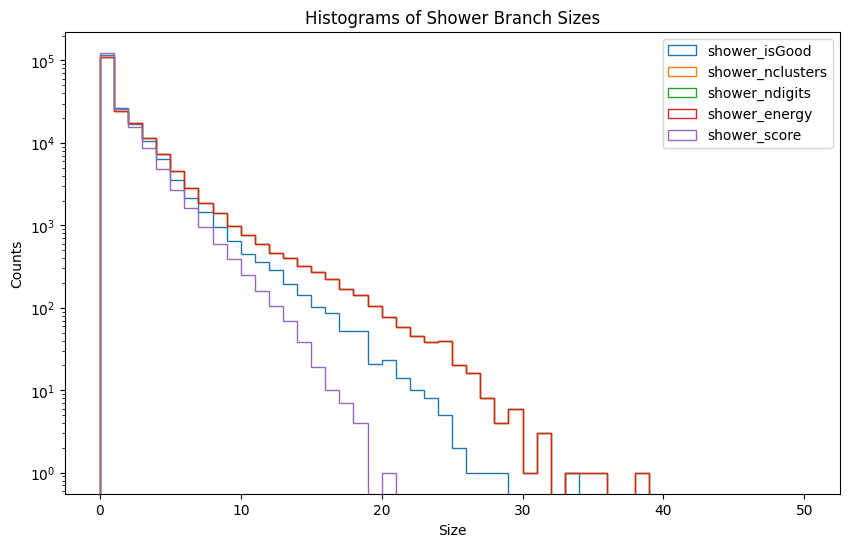

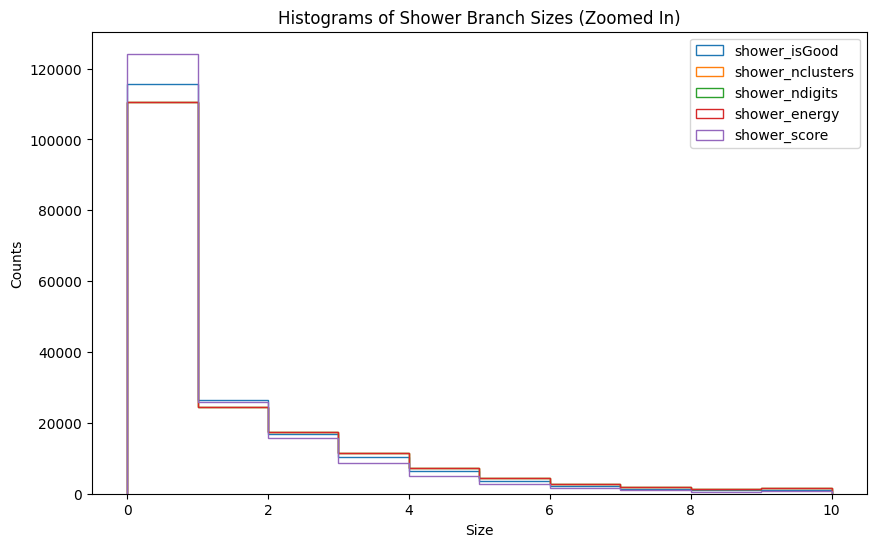

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# print histograms of sizes. use histtype=step
bins = np.linspace(0, 50, 51)
bins1=np.linspace(0, 10, 11)
fig, ax = plt.subplots(figsize=(10, 6))
fig1, ax1 = plt.subplots(figsize=(10, 6))
for branch in shower_branches:
    sz_data = showers_sz[branch]
    ax.hist(sz_data, bins=bins, histtype='step', label=branch)
    ax.set_xlabel("Size")
    ax.set_ylabel("Counts")
    ax.set_title("Histograms of Shower Branch Sizes")
    ax.legend()
ax.set_yscale("log")
fig.show()

for branch in shower_branches:
    sz_data = showers_sz[branch]
    ax1.hist(sz_data, bins=bins1, histtype='step', label=branch)
    ax1.set_xlabel("Size")
    ax1.set_ylabel("Counts")
    ax1.set_title("Histograms of Shower Branch Sizes (Zoomed In)")
    ax1.legend()

fig1.show()

In [20]:
# Check percentages of empty arrays (size=0)
for branch in shower_branches:
    sz_data = showers_sz[branch]
    total = len(sz_data)
    empty = np.sum(sz_data == 0)
    percent_empty = (empty / total) * 100
    print(f"Branch: {branch:20} | Empty arrays: {empty:6} / {total:6} ({percent_empty:.2f}%)")

Branch: shower_isGood        | Empty arrays: 115584 / 186439 (62.00%)
Branch: shower_nclusters     | Empty arrays: 110500 / 186439 (59.27%)
Branch: shower_ndigits       | Empty arrays: 110500 / 186439 (59.27%)
Branch: shower_energy        | Empty arrays: 110500 / 186439 (59.27%)
Branch: shower_score         | Empty arrays: 124198 / 186439 (66.62%)


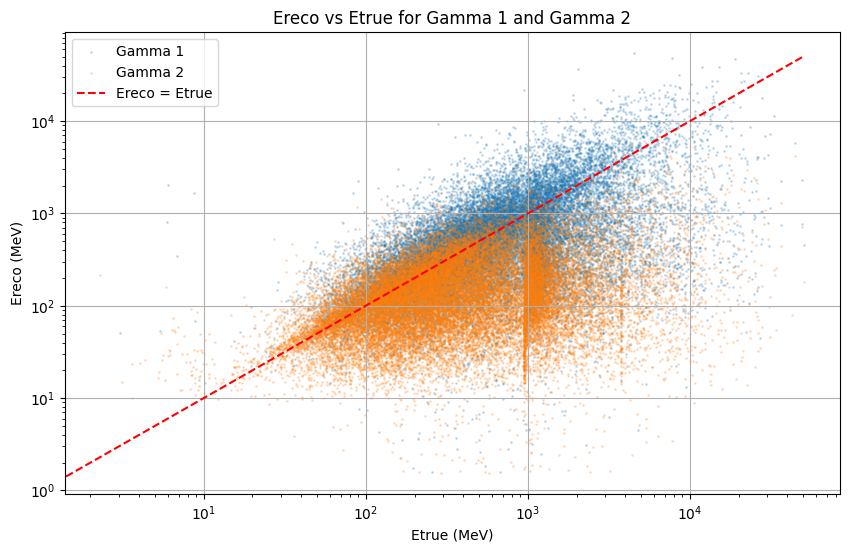

In [16]:
"""gamma1_E
gamma1_E_Old
gamma1_P
gamma1_dEdx
gamma1_dist_vtx
gamma1_energy_ecal
gamma1_energy_hcal
gamma1_energy_scal_UV
gamma1_energy_scal_X
gamma1_energy_trkr
gamma1_evis_ecal
gamma1_evis_hcal
gamma1_evis_scal_UV
gamma1_evis_scal_X
gamma1_evis_trkr
gamma1_maxZ
gamma1_phi
gamma1_px
gamma1_py
gamma1_pz
gamma1_theta
gamma1_time
gamma1_direction[3]
gamma1_end_vertex[3]
gamma1_vertex[3]
truth_gamma1_PDG
truth_gamma1_Parent_PDG
truth_gamma1_from_decay
truth_gamma1_E
truth_gamma1_Parent_E
truth_gamma1_evis_ecal
truth_gamma1_evis_hcal
truth_gamma1_evis_scal_UV
truth_gamma1_evis_scal_X
truth_gamma1_evis_total
truth_gamma1_evis_trkr
truth_gamma1_fraction
truth_gamma1_phi
truth_gamma1_px
truth_gamma1_py
truth_gamma1_pz
truth_gamma1_theta
truth_gamma1_end_vertex[3]
truth_gamma1_vertex[3]
gamma2_E
gamma2_E_Old
gamma2_P
gamma2_dEdx
gamma2_dist_vtx
gamma2_energy_ecal
gamma2_energy_hcal
gamma2_energy_scal_UV
gamma2_energy_scal_X
gamma2_energy_trkr
gamma2_evis_ecal
gamma2_evis_hcal
gamma2_evis_scal_UV
gamma2_evis_scal_X
gamma2_evis_trkr
gamma2_maxZ
gamma2_phi
gamma2_px
gamma2_py
gamma2_pz
gamma2_theta
gamma2_time
gamma2_direction[3]
gamma2_end_vertex[3]
gamma2_vertex[3]
"""

# Write code that plots Ereco over Etrue of gamma1 and gamma2

with uproot.open(file) as uf:
    tree = uf["MasterAnaDev"]
    gamma1_E = tree["gamma1_E"].array()
    truth_gamma1_E = tree["truth_gamma1_E"].array()
    gamma2_E = tree["gamma2_E"].array()
    truth_gamma2_E = tree["truth_gamma2_E"].array()
# Scatter plot for gamma1
plt.figure(figsize=(10, 6))
plt.scatter(truth_gamma1_E, gamma1_E, alpha=0.2, label="Gamma 1", s=1)
plt.scatter(truth_gamma2_E, gamma2_E, alpha=0.2, label="Gamma 2", s=1)            
plt.plot([0, max(max(truth_gamma1_E), max(truth_gamma2_E))], [0, max(max(truth_gamma1_E), max(truth_gamma2_E))], 'r--', label="Ereco = Etrue")
plt.xlabel("Etrue (MeV)")
plt.ylabel("Ereco (MeV)")
plt.title("Ereco vs Etrue for Gamma 1 and Gamma 2")
plt.legend()
plt.xscale("log")
plt.yscale("log")
plt.grid()
plt.show()


In [21]:
master_ana_dev.keys()

['eventID',
 'physEvtNum',
 'n_hyps',
 'processType',
 'primaryPart',
 'n_slices',
 'slice_numbers',
 'shared_slice',
 'vtx',
 'vtxErr',
 'E',
 'reco_vertex_batch',
 'found_truth',
 'phys_front_activity',
 'phys_energy_in_road_upstream_is_rockmuon_consistent',
 'rock_muons_removed',
 'minos_track_match',
 'minos_stub_match',
 'unknown_helicity',
 'minos_track_inside_partial_plane',
 'prim_vtx_has_misassigned_track_direction',
 'prim_vtx_has_broken_track',
 'pass_MasterAnaDev',
 'hasVetoWall',
 'VetoWalldigitsGood',
 'VetoWall_extrapnowalls',
 'VetoWall_extrapwall1',
 'VetoWall_extrapwall2',
 'VetoWall_extrapbothwalls',
 'VetoWall_MuonTrkMatchToVETOwalloff',
 'Cut_BlobDirectionBad',
 'Cut_PreFilter_Pi0',
 'EMLikeTrackMultiplicity',
 'FailContainedProng',
 'Good_Blobs',
 'HasNoBackExitingTracks',
 'HasNoVertexMismatch',
 'HasTracks',
 'ID_Hits_Post_Long',
 'NeutronMaxClusters',
 'NneutronClusters0',
 'NneutronClusters1',
 'NneutronClusters2',
 'NneutronClusters3',
 'PassNeutronMaxCluster

In [23]:
# get keys inside masterAnadev
with uproot.open(file) as uf:
    master_ana_dev = uf["MasterAnaDev"]
    print("MasterAnaDev Tree Branches:")
    for key in master_ana_dev.keys():
        print(f"  - {key}")


MasterAnaDev Tree Branches:
  - eventID
  - physEvtNum
  - n_hyps
  - processType
  - primaryPart
  - n_slices
  - slice_numbers
  - shared_slice
  - vtx
  - vtxErr
  - E
  - reco_vertex_batch
  - found_truth
  - phys_front_activity
  - phys_energy_in_road_upstream_is_rockmuon_consistent
  - rock_muons_removed
  - minos_track_match
  - minos_stub_match
  - unknown_helicity
  - minos_track_inside_partial_plane
  - prim_vtx_has_misassigned_track_direction
  - prim_vtx_has_broken_track
  - pass_MasterAnaDev
  - hasVetoWall
  - VetoWalldigitsGood
  - VetoWall_extrapnowalls
  - VetoWall_extrapwall1
  - VetoWall_extrapwall2
  - VetoWall_extrapbothwalls
  - VetoWall_MuonTrkMatchToVETOwalloff
  - Cut_BlobDirectionBad
  - Cut_PreFilter_Pi0
  - EMLikeTrackMultiplicity
  - FailContainedProng
  - Good_Blobs
  - HasNoBackExitingTracks
  - HasNoVertexMismatch
  - HasTracks
  - ID_Hits_Post_Long
  - NeutronMaxClusters
  - NneutronClusters0
  - NneutronClusters1
  - NneutronClusters2
  - NneutronClust

In [24]:
master_ana_dev.keys()

['eventID',
 'physEvtNum',
 'n_hyps',
 'processType',
 'primaryPart',
 'n_slices',
 'slice_numbers',
 'shared_slice',
 'vtx',
 'vtxErr',
 'E',
 'reco_vertex_batch',
 'found_truth',
 'phys_front_activity',
 'phys_energy_in_road_upstream_is_rockmuon_consistent',
 'rock_muons_removed',
 'minos_track_match',
 'minos_stub_match',
 'unknown_helicity',
 'minos_track_inside_partial_plane',
 'prim_vtx_has_misassigned_track_direction',
 'prim_vtx_has_broken_track',
 'pass_MasterAnaDev',
 'hasVetoWall',
 'VetoWalldigitsGood',
 'VetoWall_extrapnowalls',
 'VetoWall_extrapwall1',
 'VetoWall_extrapwall2',
 'VetoWall_extrapbothwalls',
 'VetoWall_MuonTrkMatchToVETOwalloff',
 'Cut_BlobDirectionBad',
 'Cut_PreFilter_Pi0',
 'EMLikeTrackMultiplicity',
 'FailContainedProng',
 'Good_Blobs',
 'HasNoBackExitingTracks',
 'HasNoVertexMismatch',
 'HasTracks',
 'ID_Hits_Post_Long',
 'NeutronMaxClusters',
 'NneutronClusters0',
 'NneutronClusters1',
 'NneutronClusters2',
 'NneutronClusters3',
 'PassNeutronMaxCluster

In [ ]:
#get keys inside Truth
with uproot.open(file) as uf:
    master_ana_dev = uf["Truth"]
    print("Truth Tree Branches:")
    for key in master_ana_dev.keys():
        print(f"  - {key}")


Truth Tree Branches:
  - eventID
  - truth_has_physics_event
  - truth_pass_MasterAnaDev
  - truth_is_fiducial
  - truth_reco_hasGoodObjects
  - truth_reco_isGoodVertex
  - truth_reco_isFidVol_smeared
  - truth_reco_has_muon
  - truth_reco_has_int_vtx
  - truth_N_K0
  - truth_N_chargedK
  - truth_N_gamma_pi0
  - truth_N_lambda
  - truth_N_pi0
  - truth_N_pim
  - truth_N_pip
  - truth_N_proton
  - truth_N_sigma
  - truth_hadronReweightNPaths
  - truth_hadronReweightNPoints
  - truth_in_fiducial_area
  - truth_neutronInelasticReweightNPaths
  - truth_neutronInelasticReweightNPoints
  - truth_reco_has_muon_charge
  - truth_reco_has_single_proton
  - truth_reco_is_fiducial
  - truth_reco_is_minos_match
  - truth_reco_muon_is_minos_match_stub
  - truth_reco_muon_is_minos_match_track
  - truth_reco_pass_MasterAnaDev_precuts
  - truth_targetID
  - truth_targetZ
  - truth_target_code
  - truth_vtx_module
  - truth_vtx_plane
  - truth_muon_E
  - truth_muon_px
  - truth_muon_py
  - truth_muon_pz

/tmp/ipykernel_1819/3414724346.py:55: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


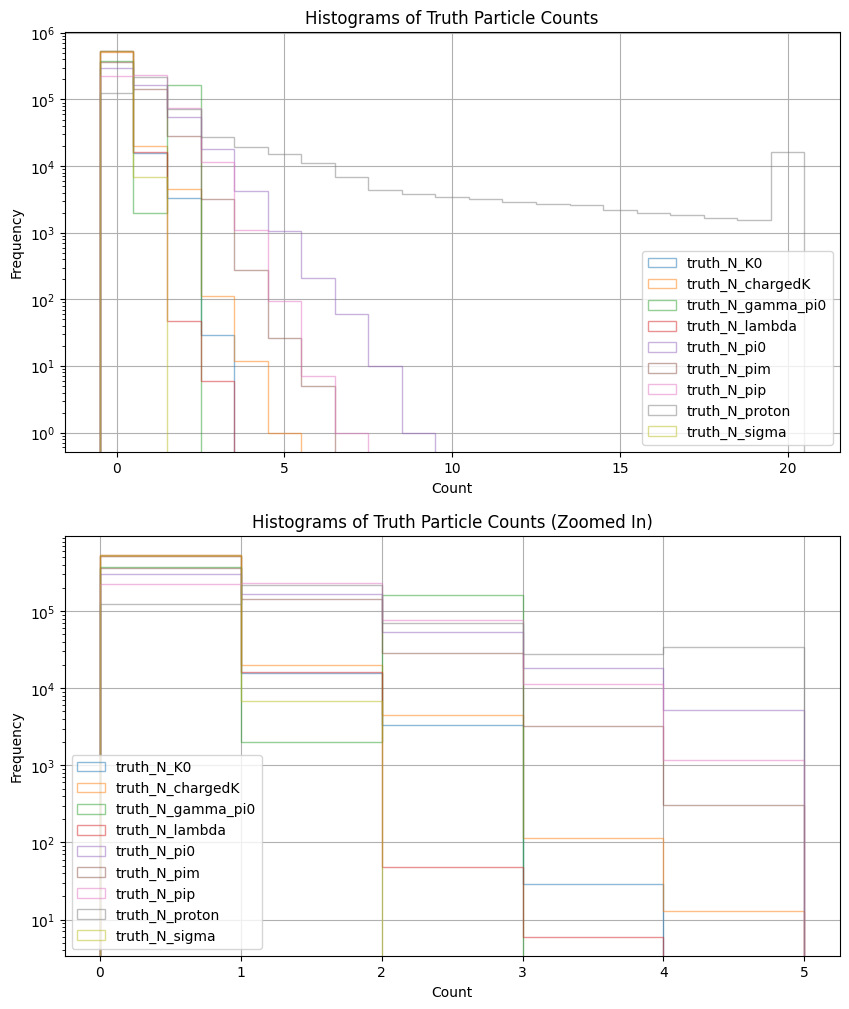

In [ ]:
# make histograms of 
'''
  - truth_N_K0
  - truth_N_chargedK
  - truth_N_gamma_pi0
  - truth_N_lambda
  - truth_N_pi0
  - truth_N_pim
  - truth_N_pip
  - truth_N_proton
  - truth_N_sigma
  '''
import matplotlib.pyplot as plt
import numpy as np
truth_branches = [
    "truth_N_K0",
    "truth_N_chargedK",
    "truth_N_gamma_pi0",
    "truth_N_lambda",
    "truth_N_pi0",
    "truth_N_pim",
    "truth_N_pip",
    "truth_N_proton",
    "truth_N_sigma"
]

sum_of_truth_particles = None # event by event sum

with uproot.open(file) as uf:
    truth_tree = uf["Truth"]
    bins = np.linspace(0, 20, 21)
    bins1 = np.linspace(0, 5, 6)
    fig, ax = plt.subplots(2, 1, figsize=(10, 12)) # for bins and bins1
    for branch in truth_branches:
        data = truth_tree[branch].array()
        if sum_of_truth_particles is None:
            sum_of_truth_particles = data.to_numpy()
        else:
            sum_of_truth_particles += data.to_numpy()

        ax[0].hist(data, bins=np.arange(-0.5, max(data)+1.5, 1), alpha=0.5, label=branch, histtype='step')
        ax[1].hist(data, bins=bins1, alpha=0.5, label=branch, histtype='step')
    ax[0].set_xlabel("Count")
    ax[0].set_ylabel("Frequency")
    ax[0].set_title("Histograms of Truth Particle Counts")
    ax[0].legend()
    ax[0].set_yscale("log")
    ax[0].grid()
    ax[1].set_xlabel("Count")
    ax[1].set_ylabel("Frequency")
    ax[1].set_title("Histograms of Truth Particle Counts (Zoomed In)")
    ax[1].legend()
    ax[1].set_yscale("log")
    ax[1].grid()
    fig.show()



/tmp/ipykernel_1819/1972798620.py:6: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


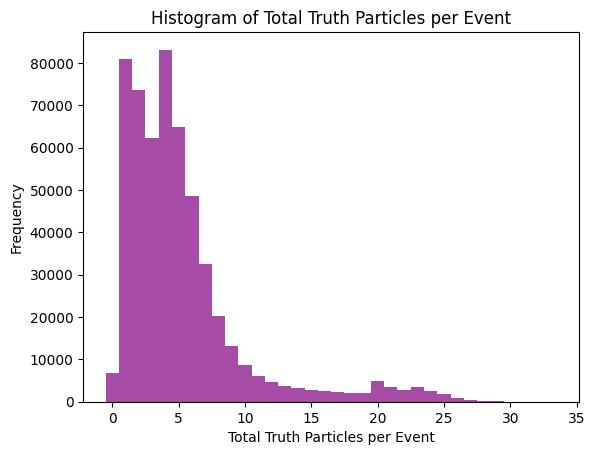

In [19]:
fig, ax = plt.subplots()
ax.hist(sum_of_truth_particles, bins=np.arange(-0.5, max(sum_of_truth_particles)+1.5, 1), alpha=0.7, color='purple', histtype='stepfilled')
ax.set_xlabel("Total Truth Particles per Event")
ax.set_ylabel("Frequency")
ax.set_title("Histogram of Total Truth Particles per Event")
fig.show()


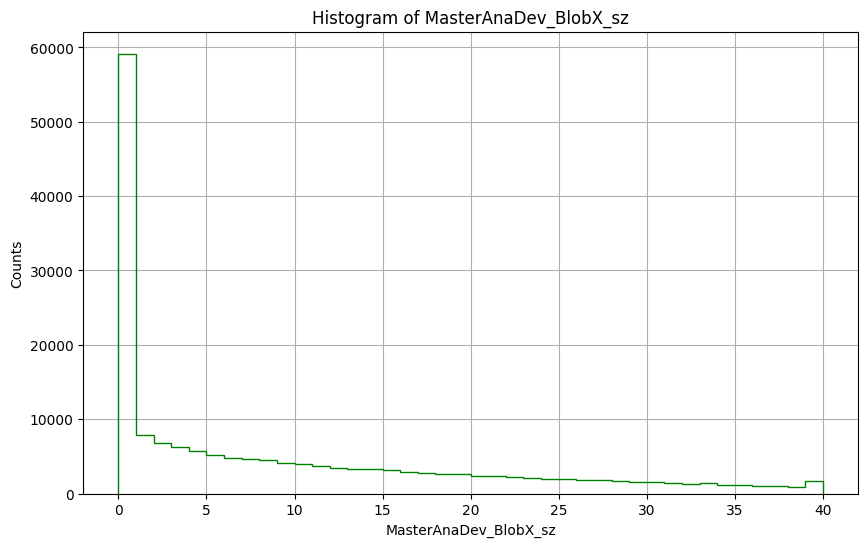

MasterAnaDev_BlobX_sz: Empty arrays:  59150 / 186439 (31.73%)


In [14]:
# histogram of MasterAnaDev_BlobX_sz
with uproot.open(file) as uf:
    tree = uf["MasterAnaDev"]
    blobX_sz = tree["MasterAnaDev_BlobX_sz"].array()
    plt.figure(figsize=(10, 6))
    plt.hist(blobX_sz, bins=np.linspace(0, 40, 41), histtype='step', color='green')
    plt.xlabel("MasterAnaDev_BlobX_sz")
    plt.ylabel("Counts")
    plt.title("Histogram of MasterAnaDev_BlobX_sz")
    plt.grid()
    plt.show()
# how many % are 0
total = len(blobX_sz)
empty = np.sum(blobX_sz == 0)
percent_empty = (empty / total) * 100
print(f"MasterAnaDev_BlobX_sz: Empty arrays: {empty:6} / {total:6} ({percent_empty:.2f}%)")

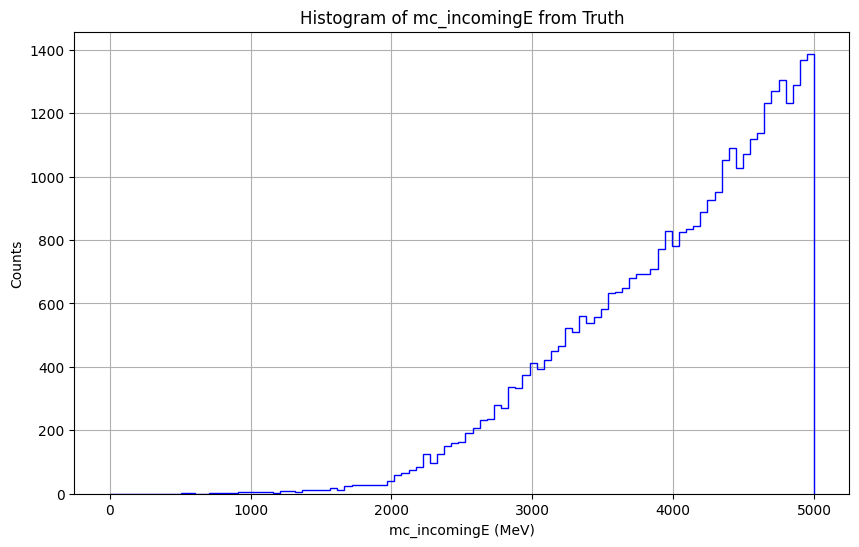

In [4]:
# get final state gen particles - from Truth tree (mc_FSPartE, mc_FSPartPx, mc_FSPartPy, mc_FSPartPz)
with uproot.open(file) as uf:
    truth_tree = uf["Truth"]
    mc_FSPartE = truth_tree["mc_FSPartE"].array()
    mc_FSPartPx = truth_tree["mc_FSPartPx"].array()
    mc_FSPartPy = truth_tree["mc_FSPartPy"].array()
    mc_FSPartPz = truth_tree["mc_FSPartPz"].array()
    mc_FSPartPDG = truth_tree["mc_FSPartPDG"].array()
    mc_incomingE = truth_tree["mc_incomingE"].array().to_numpy()


In [5]:
mc_incomingE

array([ 3849.10061369,  7704.85281831, 16958.06921095, ...,
        5251.97203677,  6811.07447392,  8383.09747911])

In [6]:
mc_FSPartE[2].to_numpy().sum()

23531.719187471434

In [7]:
mc_FSPartPDG

<Array [[13, 3222, 321], ..., [14, 22, ..., -211]] type='544343 * var * int32'>

In [8]:
# print the muon energies
muon_energies = []
for i in range(len(mc_FSPartPDG)):
    pdg_array = mc_FSPartPDG[i].to_numpy()
    energy_array = mc_FSPartE[i].to_numpy()
    muon_mask = (pdg_array == 13) | (pdg_array == -13) # PDG codes for muon and anti-muon
    muon_energy = energy_array[muon_mask]
    muon_energies.append(muon_energy)
muon_energies

KeyboardInterrupt: 